In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [121]:
filtered_IAFs_database = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\AIF_Babiloni\filtered_IAFs_fooof_database.feather")
# PW REL
recombat_pw_rel_F= pd.read_excel(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\AIF_Babiloni\results_harmonize\recombat\pw_rel_canonic_roiF_SITE_age_group_recombat.xlsx", sheet_name='harmonizeSITE_age_group')
recombat_pw_rel_C= pd.read_excel(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\AIF_Babiloni\results_harmonize\recombat\pw_rel_canonic_roiC_SITE_age_group_recombat.xlsx",sheet_name='harmonizeSITE_age_group')
recombat_pw_rel_P= pd.read_excel(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\AIF_Babiloni\results_harmonize\recombat\pw_rel_canonic_roiP_SITE_age_group_recombat.xlsx", sheet_name='harmonizeSITE_age_group')
recombat_pw_rel_O= pd.read_excel(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\AIF_Babiloni\results_harmonize\recombat\pw_rel_canonic_roiO_SITE_age_group_recombat.xlsx", sheet_name='harmonizeSITE_age_group')
recombat_pw_rel_PO= pd.read_excel(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\AIF_Babiloni\results_harmonize\recombat\pw_rel_canonic_roiPO_SITE_age_group_recombat.xlsx",sheet_name='harmonizeSITE_age_group')
#  OSC REL
recombat_pw_osc_F= pd.read_excel(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\AIF_Babiloni\results_harmonize\recombat\osc_pw_rel_canonic_roiF_SITE_age_group_recombat.xlsx",sheet_name='harmonizeSITE_age_group')
recombat_pw_osc_C= pd.read_excel(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\AIF_Babiloni\results_harmonize\recombat\osc_pw_rel_canonic_roiC_SITE_age_group_recombat.xlsx",sheet_name='harmonizeSITE_age_group')
recombat_pw_osc_P= pd.read_excel(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\AIF_Babiloni\results_harmonize\recombat\osc_pw_rel_canonic_roiP_SITE_age_group_recombat.xlsx",sheet_name='harmonizeSITE_age_group')
recombat_pw_osc_O= pd.read_excel(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\AIF_Babiloni\results_harmonize\recombat\osc_pw_rel_canonic_roiO_SITE_age_group_recombat.xlsx",sheet_name='harmonizeSITE_age_group')
recombat_pw_osc_PO= pd.read_excel(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\AIF_Babiloni\results_harmonize\recombat\osc_pw_rel_canonic_roiPO_SITE_age_group_recombat.xlsx",sheet_name='harmonizeSITE_age_group')

In [163]:
import pandas as pd
from scipy.stats import ttest_ind
import pingouin as pg

grupo_col = 'group'
edad_col = 'age'
grupos_clinicos = ['MCI', 'AD', 'PD', 'VD', 'ACr']

df = recombat_pw_rel_F[[grupo_col, edad_col]].dropna()
hc = df[df[grupo_col] == 'HC'][edad_col].dropna()

resultados = []

for grupo in grupos_clinicos:
    try:
        grupo_clinico = df[df[grupo_col] == grupo][edad_col].dropna()
        resultado = {
            'group': grupo,
            'variable': 'age',
            'mean_HC': round(hc.mean(), 2),
            'std_HC': round(hc.std(), 2),
            'n_HC': len(hc),
            'mean_group': round(grupo_clinico.mean(), 2),
            'std_group': round(grupo_clinico.std(), 2),
            'n_group': len(grupo_clinico),
            'p_value': ttest_ind(hc, grupo_clinico, equal_var=False)[1],
            'cohens_d': pg.compute_effsize(hc, grupo_clinico, eftype='cohen')
        }
    except Exception as e:
        resultado = {
            'group': grupo,
            'variable': 'age',
            'mean_HC': None,
            'std_HC': None,
            'n_HC': None,
            'mean_group': None,
            'std_group': None,
            'n_group': None,
            'p_value': None,
            'cohens_d': None
        }
        print(f"Error con grupo {grupo}: {e}")
    
    resultados.append(resultado)

df_resultados = pd.DataFrame(resultados)

# Notación científica para el p-value
df_resultados['p_value'] = df_resultados['p_value'].apply(lambda x: f"{x:.2e}" if pd.notnull(x) else x)


In [164]:
df_resultados

,group,variable,mean_HC,std_HC,n_HC,mean_group,std_group,n_group,p_value,cohens_d
0,MCI,age,49.11,17.77,1196,73.69,8.92,349,2.74e-184,-1.516821
1,AD,age,49.11,17.77,1196,76.42,8.20,130,3.37e-93,-1.599018
2,PD,age,49.11,17.77,1196,70.15,8.33,68,4.56e-35,-1.209027
3,VD,age,49.11,17.77,1196,78.13,6.10,54,1.24e-51,-1.664410
4,ACr,age,49.11,17.77,1196,31.33,6.99,39,1.79e-20,1.013852


In [158]:
df_resultados.p_age

0    2.744781e-184
1     3.373366e-93
2     4.562109e-35
3     1.242028e-51
4     1.789901e-20
Name: p_age, dtype: float64

In [134]:
recombat_pw_osc_C

,subject,group,SITE,age,harm_osc_pw_canonic_theta_roiC,harm_osc_pw_canonic_alpha1_roiC,harm_osc_pw_canonic_alpha2_roiC,harm_osc_pw_canonic_beta1_roiC,harm_osc_pw_canonic_beta2_roiC,harm_osc_pw_canonic_beta3_roiC,harm_osc_pw_canonic_gamma_roiC,harm_exponent_roiC,harm_offset_roiC,harmonized-pca-one,harmonized-pca-two,harmonized-umap-one,harmonized-umap-two
0,sub-001,HC,Dortmund,60,0.008987,0.063643,0.128450,0.120378,0.124041,0.414569,0.081594,1.169663,-1.124770,3.182343,-0.394948,11.313561,4.639608
1,sub-002,HC,Dortmund,67,0.185135,0.315795,0.071189,0.133189,0.047176,0.122274,0.096425,1.025273,-1.315103,-1.983728,-0.984698,-0.308729,0.637645
2,sub-003,HC,Dortmund,44,0.039169,0.076148,0.125043,0.236670,0.105751,0.201658,0.150560,1.372373,-0.729796,1.889317,1.557396,8.932960,9.870815
3,sub-004,HC,Dortmund,24,0.029310,0.245794,0.188589,0.096634,0.059559,0.158546,0.151641,1.144840,-0.983750,-0.521446,-0.454328,5.009971,2.747677
4,sub-005,HC,Dortmund,48,0.050043,0.168663,0.128785,0.117862,0.068160,0.197369,0.192763,1.321897,-0.757610,0.548507,1.395627,5.694889,5.353796
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1832,sub-DCLSTIM062,HC,Madrid,85,0.156802,0.240041,0.089070,0.119281,0.067022,0.163838,0.133279,1.337794,-0.934891,-0.983792,0.972741,2.482204,5.067741
1833,sub-DCLSTIM063,MCI,Madrid,84,0.205741,0.105530,0.042852,0.217480,0.091068,0.195140,0.083213,1.522227,-0.885763,0.074419,2.022721,4.066517,8.882160
1834,sub-DCLSTIM065,HC,Madrid,84,0.233719,0.342156,0.103113,0.208449,0.049762,0.066140,0.027872,1.391404,-1.394535,-3.365417,-0.839530,0.138717,1.220295
1835,sub-DCLSTIM067,HC,Madrid,81,0.158043,0.182768,0.062514,0.236730,0.069261,0.154605,0.084251,1.425240,-0.969508,-0.596327,1.133885,2.424340,7.985021


In [144]:
import pandas as pd

# Lista de DataFrames por ROI
osc_roi_dfs = [recombat_pw_osc_F, recombat_pw_osc_C, recombat_pw_osc_P, recombat_pw_osc_O, recombat_pw_osc_PO]
pw_roi_dfs = [recombat_pw_rel_F, recombat_pw_rel_C, recombat_pw_rel_P, recombat_pw_rel_O, recombat_pw_rel_PO]

# Función para extraer columnas relevantes por ROI
def get_feature_cols(df, osc=True):
    if osc:
        return [col for col in df.columns if col.startswith('harm_osc_pw_') or col.startswith('harm_exponent_') or col.startswith('harm_offset_')]
    else:
        return [col for col in df.columns if col.startswith('harm_pw_') or col.startswith('harm_IAFp_')]

# === Inicializar DataFrames base ===
osc_combined = osc_roi_dfs[0][['subject', 'group', 'SITE', 'age']].copy()
pw_combined  = pw_roi_dfs[0][['subject', 'group', 'SITE', 'age']].copy()

# === PROCESAMIENTO OSCILATORIO ===
osc_feature_cols = list(set().union(*[get_feature_cols(df) for df in osc_roi_dfs]))

# Inicializar acumuladores y contadores
for col in osc_feature_cols:
    osc_combined[col] = 0
    osc_combined[f'{col}_count'] = 0

# Sumar solo donde la columna exista
for df in osc_roi_dfs:
    for col in osc_feature_cols:
        if col in df.columns:
            osc_combined[col] += df[col]
            osc_combined[f'{col}_count'] += 1

# Promediar dividiendo por número real de ROIs con datos
for col in osc_feature_cols:
    count_col = f'{col}_count'
    valid_div = osc_combined[count_col].replace(0, pd.NA)
    osc_combined[col] = osc_combined[col] / valid_div
    osc_combined.drop(columns=[count_col], inplace=True)

# === PROCESAMIENTO DE POWER RELATIVO ===
pw_feature_cols = list(set().union(*[get_feature_cols(df, osc=False) for df in pw_roi_dfs]))

# Inicializar acumuladores y contadores
for col in pw_feature_cols:
    pw_combined[col] = 0
    pw_combined[f'{col}_count'] = 0

# Sumar solo donde la columna exista
for df in pw_roi_dfs:
    for col in pw_feature_cols:
        if col in df.columns:
            pw_combined[col] += df[col]
            pw_combined[f'{col}_count'] += 1

# Promediar dividiendo por número real de ROIs con datos
for col in pw_feature_cols:
    count_col = f'{col}_count'
    valid_div = pw_combined[count_col].replace(0, pd.NA)
    pw_combined[col] = pw_combined[col] / valid_div
    pw_combined.drop(columns=[count_col], inplace=True)


In [146]:
# Extraer nombres de bandas
bandas = ['theta', 'alpha1', 'alpha2', 'beta1', 'beta2', 'beta3', 'gamma']
pw_avg = pw_combined[['subject', 'group', 'SITE', 'age']].copy()

# Para cada banda, buscar columnas de todas las ROIs y promediar
for banda in bandas:
    roi_cols = [col for col in pw_combined.columns if f'canonic_{banda}_roi' in col]
    pw_avg[f'{banda}_mean'] = pw_combined[roi_cols].mean(axis=1)

# Exponent y offset también:
pw_avg['IAFp_mean'] = pw_combined[[col for col in pw_combined.columns if 'harm_IAFp_roi' in col]].mean(axis=1)

# Resultado
pw_avg.head()

,subject,group,SITE,age,theta_mean,alpha1_mean,alpha2_mean,beta1_mean,beta2_mean,beta3_mean,gamma_mean,IAFp_mean
0,sub-001,HC,Dortmund,60,0.033515,0.269027,0.177139,0.087225,0.066371,0.133554,0.017068,10.651550
1,sub-002,HC,Dortmund,67,0.200807,0.337780,0.062958,0.082911,0.023724,0.050858,0.027282,9.054072
2,sub-003,HC,Dortmund,44,0.062699,0.102406,0.173865,0.151303,0.046513,0.056396,0.022742,11.237580
3,sub-004,HC,Dortmund,24,0.047313,0.316567,0.235916,0.047958,0.028751,0.037599,0.023543,10.361967
4,sub-005,HC,Dortmund,48,0.063890,0.280101,0.163153,0.060810,0.031301,0.049926,0.030150,10.398804


In [147]:

# Extraer nombres de bandas
bandas = ['theta', 'alpha1', 'alpha2', 'beta1', 'beta2', 'beta3', 'gamma']
osc_avg = osc_combined[['subject', 'group', 'SITE', 'age']].copy()

# Para cada banda, buscar columnas de todas las ROIs y promediar
for banda in bandas:
    roi_cols = [col for col in osc_combined.columns if f'canonic_{banda}_roi' in col]
    osc_avg[f'{banda}_mean'] = osc_combined[roi_cols].mean(axis=1)

# Exponent y offset también:
osc_avg['exponent_mean'] = osc_combined[[col for col in osc_combined.columns if 'harm_exponent_roi' in col]].mean(axis=1)
osc_avg['offset_mean'] = osc_combined[[col for col in osc_combined.columns if 'harm_offset_roi' in col]].mean(axis=1)

# Resultado
osc_avg.head()


,subject,group,SITE,age,theta_mean,alpha1_mean,alpha2_mean,beta1_mean,beta2_mean,beta3_mean,gamma_mean,exponent_mean,offset_mean
0,sub-001,HC,Dortmund,60,0.007908,0.199691,0.159216,0.115108,0.107451,0.286075,0.077449,1.336265,-1.084919
1,sub-002,HC,Dortmund,67,0.149100,0.311357,0.074565,0.129005,0.049556,0.129709,0.107059,0.997845,-1.337179
2,sub-003,HC,Dortmund,44,0.030931,0.083762,0.176984,0.227060,0.097251,0.168082,0.132978,1.437402,-0.797595
3,sub-004,HC,Dortmund,24,0.025224,0.299865,0.225748,0.088307,0.066903,0.123736,0.110493,1.263969,-1.096917
4,sub-005,HC,Dortmund,48,0.036681,0.250181,0.175585,0.105278,0.067757,0.152211,0.145992,1.313497,-0.888978


In [148]:
def plot_average_spectrum_by_group(data, freqs_ref, component, component_name, ax, legend_handles_labels):
    """
    Gráfica el promedio del componente para todos los electrodos de interés combinados,
    comparando entre grupos sin distinguir por sitio.
    """
    data = data[data['group'].isin(['HC', 'MCI', 'AD', 'ACr', 'PD', 'VD'])]
    groups = data['group'].unique()
    data['subject_site'] = data['subject'].astype(str) + '_' + data['SITE'].astype(str)
    electrodes_of_interest = ['FP1', 'FP2', 'C3', 'C4', 'O1', 'O2', 'P7', 'P8']

    for group in groups:
        group_data = data[data['group'] == group]
        subjects = group_data['subject_site'].unique()
        all_group_data = []

        for subject_site in subjects:
            subject_data = group_data[group_data['subject_site'] == subject_site]
            subject_roi_data = []

            for electrode in electrodes_of_interest:
                electrode_data = subject_data[subject_data['Sensors'] == electrode]
                if not electrode_data.empty:
                    freqs = electrode_data['freqs'].values[0]
                    comp_data = electrode_data[component].values[0]
                    interpolated = np.interp(freqs_ref, freqs[:len(comp_data)], comp_data)
                    subject_roi_data.append(interpolated)

            if subject_roi_data:
                mean_roi_subject = np.mean(subject_roi_data, axis=0)
                all_group_data.append(mean_roi_subject)

        if all_group_data:
            average_group_data = np.mean(all_group_data, axis=0)
            line, = ax.plot(freqs_ref, average_group_data, label=f'{group} (n={len(all_group_data)})', linewidth=2.5)
            if group not in legend_handles_labels:
                legend_handles_labels[group] = line

    ax.axvspan(6, 8.5, color='gray', alpha=0.3)
    ylim = ax.get_ylim()
    ax.text(7.25, ylim[0] + 0.05 * (ylim[1] - ylim[0]), r'$\theta$', fontsize=14, ha='center', va='center')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Power')
    ax.set_title(component_name, fontsize=14, fontweight='bold',pad=15)
    ax.set_xlim([1.5, 40])
    if component == 'psd':
        ax.set_yscale('log')
    ax.grid(False)


In [149]:
from pygam import LinearGAM, s, f
import pandas as pd
from scipy.stats import ttest_ind
import numpy as np

def compute_cohens_d(x, y):
    """Calcula el tamaño del efecto tipo d de Cohen."""
    nx = len(x)
    ny = len(y)
    pooled_sd = np.sqrt(((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / (nx + ny - 2))
    return (np.mean(x) - np.mean(y)) / pooled_sd

def gam_group_comparison(df, feature_col, ref_group='HC', group_col='group'):
    results = []

    # Asegurarse que las columnas necesarias existen
    assert feature_col in df.columns, f"{feature_col} no está en el DataFrame"

    # Comparar HC vs cada grupo clínico por separado
    clinical_groups = df[group_col].unique()
    clinical_groups = [g for g in clinical_groups if g != ref_group]

    for target_group in clinical_groups:
        subdf = df[df[group_col].isin([ref_group, target_group])].copy()
        subdf['group_code'] = (subdf[group_col] == target_group).astype(int)

        # Asegurarse de que hay suficientes muestras
        if subdf['group_code'].nunique() < 2:
            continue

        try:
            X = subdf[['age', 'group_code']]
            y = subdf[feature_col]

            gam = LinearGAM(s(0) + f(1)).fit(X, y)
            pval = gam.statistics_['p_values'][1]

            # Calcular tamaño del efecto (Cohen’s d)
            val_ref = subdf[subdf['group_code'] == 0][feature_col]
            val_target = subdf[subdf['group_code'] == 1][feature_col]
            d = compute_cohens_d(val_ref, val_target)

            results.append({
                'feature': feature_col,
                'group': target_group,
                'p_value': pval,
                'cohens_d': d,
                'n_HC': len(val_ref),
                'n_group': len(val_target)
            })
        except Exception as e:
            print(f"Error con {target_group} - {feature_col}: {e}")

    return pd.DataFrame(results)


In [150]:
df_results = gam_group_comparison(pw_avg, feature_col='IAFp_mean')
print(df_results)

     feature group       p_value  cohens_d  n_HC  n_group
0  IAFp_mean   MCI  2.564805e-05  0.899032  1196      349
1  IAFp_mean   ACr  3.032718e-01 -0.546997  1196       39
2  IAFp_mean    AD  4.999367e-03  1.011353  1196      130
3  IAFp_mean    PD  1.008232e-06  1.080236  1196       68
4  IAFp_mean    VD  1.198771e-08  1.567814  1196       54
5  IAFp_mean     F  3.086528e-02       NaN  1196        1


In [151]:
df_results = gam_group_comparison(pw_avg, feature_col='gamma_mean')
print(df_results)

      feature group   p_value  cohens_d  n_HC  n_group
0  gamma_mean   MCI  0.598644 -0.102437  1196      349
1  gamma_mean   ACr  0.003165 -0.303500  1196       39
2  gamma_mean    AD  0.427918 -0.026409  1196      130
3  gamma_mean    PD  0.088167  0.023123  1196       68
4  gamma_mean    VD  0.017288  0.193077  1196       54
5  gamma_mean     F  0.889728       NaN  1196        1


In [152]:
def violin_with_final_style(ax, data, x, y, title,group_order, group_palette):
    import seaborn as sns
    import numpy as np

    # Violinplot con alpha bajo
    sns.violinplot(
        data=data, x=x, y=y, ax=ax,
        order=group_order,
        palette={k: group_palette[k] for k in group_order},
        inner=None, cut=0, linewidth=1, alpha=0.3, zorder=1
    )

    # Puntos del mismo color que el grupo, sin borde, DETRÁS de la caja
    for i, group in enumerate(group_order):
        group_data = data[data[x] == group]
        x_jitter = np.random.normal(loc=i, scale=0.08, size=len(group_data))
        ax.scatter(
            x_jitter, group_data[y],
            color=group_palette[group],
            s=20, alpha=0.5, edgecolors='none', zorder=2  # sin contorno, detrás
        )

    # Boxplot blanco encima del violin y los puntos
    sns.boxplot(
        data=data, x=x, y=y, ax=ax,
        order=group_order,
        width=0.15, showcaps=True, fliersize=0,
        boxprops=dict(facecolor='white', edgecolor='black', linewidth=1.5, zorder=3),
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(color='black', linewidth=1),
        capprops=dict(color='black', linewidth=1)
    )
    
    ax.set_title(title,fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('')
    ax.set_ylabel('')
    


In [153]:
def annotate_pval_and_d(ax, feature_name, results_dict, offset=0.02):
    group_order = ['HC', 'MCI', 'ACr', 'AD', 'PD', 'VD']

    ylim = ax.get_ylim()
    y_max = ylim[1]

    for i, group in enumerate(group_order):
        if group == 'HC':
            continue
        key = (feature_name, group)
        if key in results_dict:
            pval = results_dict[key]['p']
            dval = results_dict[key]['d']
            if pval < 0.05:
                txt = f"*p={pval:.2g}\nd={dval:.2f}"
            else:
                txt = f"p={pval:.2g}\nd={dval:.2f}"
            ax.text(i, y_max - offset*(y_max - ylim[0]), txt,
                    ha='center', va='bottom',
                    fontsize=10, color='black', fontstyle='italic')


C:\Users\Luisa\AppData\Local\Temp\ipykernel_12952\3234511850.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Luisa\AppData\Local\Temp\ipykernel_12952\3234511850.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Luisa\AppData\Local\Temp\ipykernel_12952\3234511850.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Luisa\AppData\Local\Temp\ipykernel_12952\3234511850.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable 

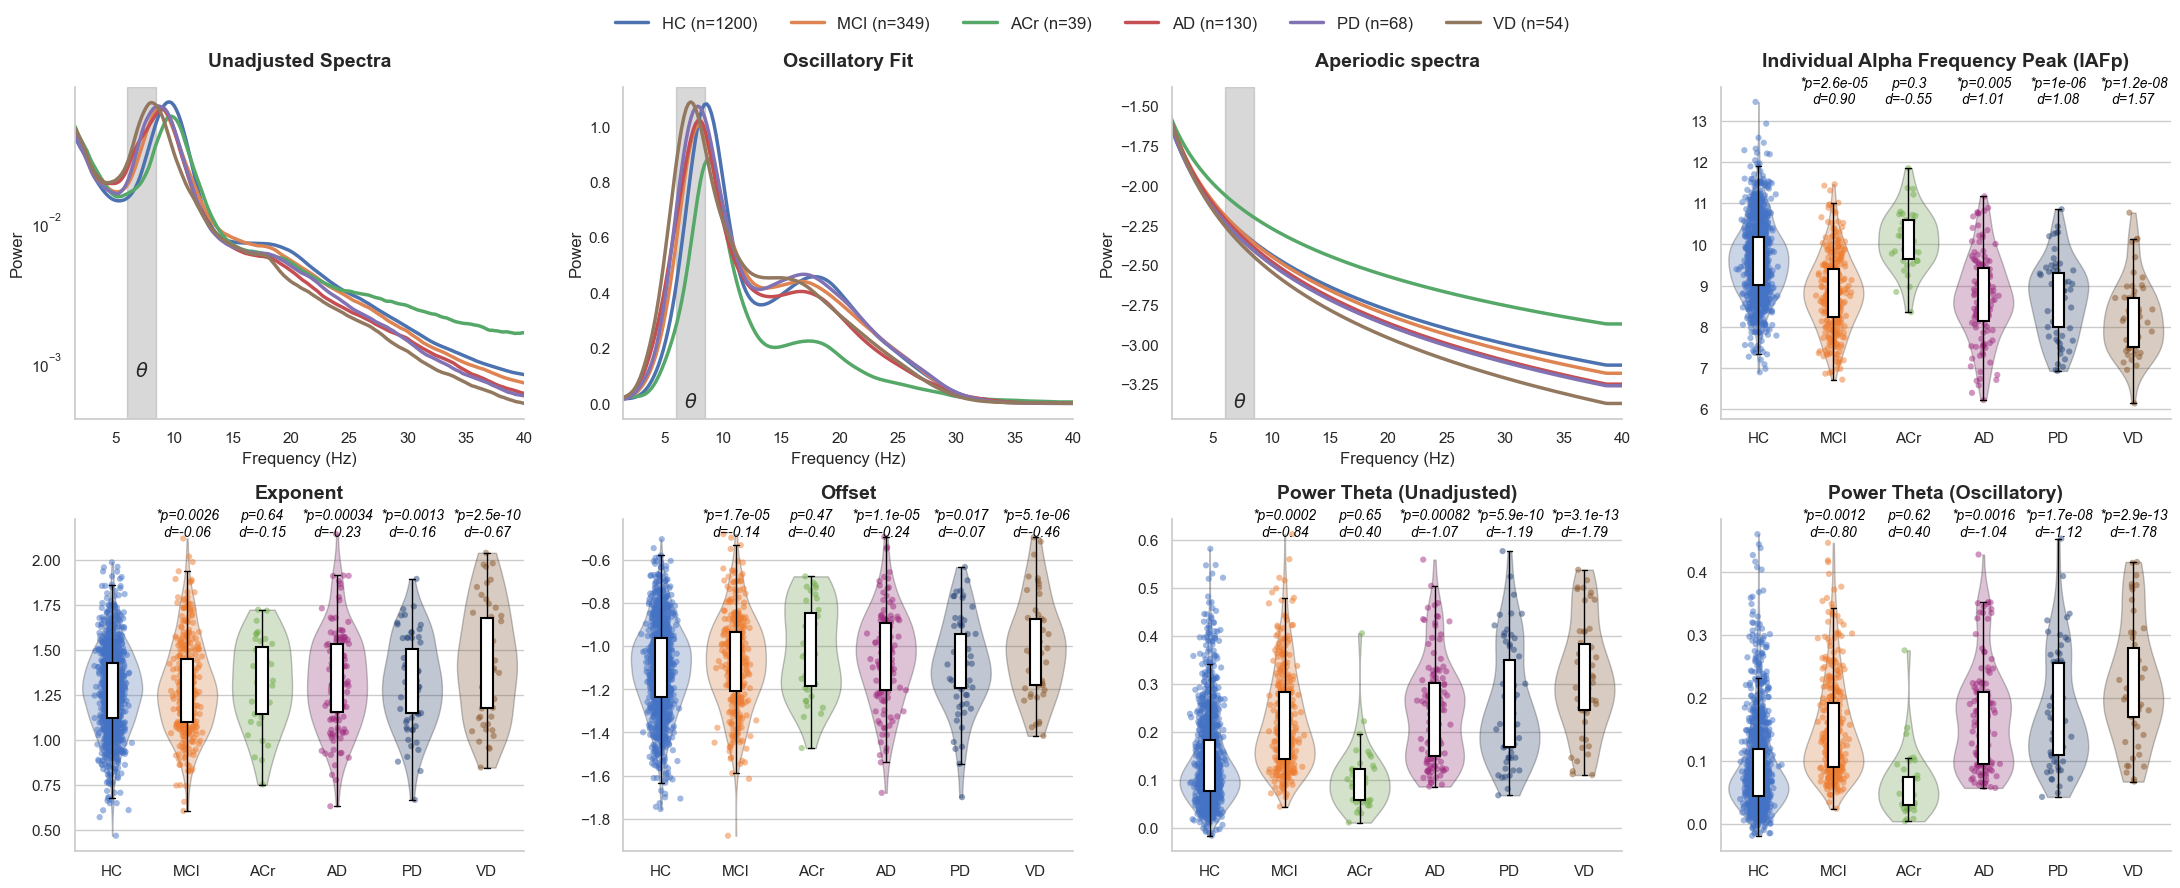

In [154]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Mapeo de grupos
group_mapping = {"DTA": "AD", "A": "AD", "SAN": None, "F": None}
filtered_IAFs_database['group'] = filtered_IAFs_database['group'].replace(group_mapping)
filtered_IAFs_database = filtered_IAFs_database[filtered_IAFs_database['group'].notna()]

# Orden y colores por grupo
group_order = ['HC', 'MCI', 'ACr', 'AD', 'PD', 'VD']
group_palette = {
    'HC': '#4472C4',
    'MCI': '#ED7D31',
    'ACr': '#70AD47',
    'AD': '#A02C7F',
    'PD': '#264478',
    'VD': '#8B572A'
}


# Crear figura
sns.set(style="whitegrid")
freqs_ref = np.linspace(1, 40, 200)
fig, axes = plt.subplots(2, 4, figsize=(22, 10),sharex=False, sharey=False)
legend_handles_labels = {}

for row in axes:
    for ax in row:
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)

# Fila 1: espectros promedio y exponent/offset
plot_average_spectrum_by_group(filtered_IAFs_database, freqs_ref, 'psd', 'Unadjusted Spectra', axes[0, 0], legend_handles_labels)
plot_average_spectrum_by_group(filtered_IAFs_database, freqs_ref, 'oscilatory_psd', 'Oscillatory Fit', axes[0, 1], legend_handles_labels)
plot_average_spectrum_by_group(filtered_IAFs_database, freqs_ref, 'aperiodic_comp', 'Aperiodic spectra', axes[0, 2], legend_handles_labels)

violin_with_final_style(axes[0, 3], pw_avg, 'group', 'IAFp_mean', 'Individual Alpha Frequency Peak (IAFp)',group_order=group_order, group_palette=group_palette)
violin_with_final_style(axes[1, 0], osc_avg, 'group', 'exponent_mean', 'Exponent',group_order=group_order, group_palette=group_palette)
violin_with_final_style(axes[1, 1], osc_avg, 'group', 'offset_mean', 'Offset',group_order=group_order, group_palette=group_palette)
violin_with_final_style(axes[1, 2], pw_avg, 'group', 'theta_mean', 'Power Theta (Unadjusted)',group_order=group_order, group_palette=group_palette)
violin_with_final_style(axes[1, 3], osc_avg, 'group', 'theta_mean', 'Power Theta (Oscillatory)',group_order=group_order, group_palette=group_palette)
#violin_with_final_style(axes[1, 2], filtered_IAFs_database, 'group', 'CF_extalpha', 'Central Frequency (CF)',group_order=group_order, group_palette=group_palette)


features = ['IAFp_mean','exponent_mean', 'offset_mean', 'theta_mean', 'theta_mean']
axes_pos = [(0, 3), (1, 0),(1, 1),(1,2), (1, 3)]  # Ajustá esto según layout
datasets = [pw_avg, osc_avg, osc_avg, pw_avg, osc_avg]

for feat, pos, data in zip(features, axes_pos, datasets):
    res = gam_group_comparison(data, feat)
    res_dict = {(feat, r['group']): {'p': r['p_value'], 'd': r['cohens_d']} for _, r in res.iterrows()}
    annotate_pval_and_d(axes[pos[0], pos[1]], feat, res_dict, offset=0.06)


# Leyenda global
handles = list(legend_handles_labels.values())
labels = [h.get_label() for h in handles]
fig.legend(
    handles, labels,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.95),  
    ncol=len(labels),
    frameon=False,
    fontsize=12
)

fig.suptitle( '')
plt.tight_layout(rect=[0, 0.1, 1, 0.98])
plt.savefig(r'D:\MulticentersEEG\graphs_thesis_LMZS\features_theta.pdf', bbox_inches='tight', dpi=300)
plt.savefig(r'D:\MulticentersEEG\graphs_thesis_LMZS\features_theta.svg', bbox_inches='tight', dpi=300)
plt.show()


In [50]:
import pandas as pd

# ---------- 1. Función auxiliar ----------
def add_uid(df):
    """Añade columna uid = subject|SITE y devuelve el df sin NaNs en la feature pasada."""
    df = df.copy()
    df['uid'] = df['subject'].astype(str) + '|' + df['SITE'].astype(str)
    return df

# ---------- 2. DataFrame para CF ----------
cf_df = add_uid(filtered_IAFs_database)
cf_df = cf_df[cf_df['CF_extalpha'].notna()]           # solo sujetos con CF

# ---------- 3. DataFrame para IAFp ----------
iafp_df = add_uid(pw_avg)
iafp_df = iafp_df[iafp_df['IAFp_mean'].notna()]       # solo sujetos con IAFp

# ---------- 4. Conteo de sujetos únicos por grupo ----------
cf_counts   = cf_df.groupby('group')['uid'].nunique().rename('CF')
iafp_counts = iafp_df.groupby('group')['uid'].nunique().rename('IAFp')

counts = pd.concat([cf_counts, iafp_counts], axis=1).fillna(0).astype(int)
counts['Δ (CF-IAFp)'] = counts['CF'] - counts['IAFp']
print(counts)

# ---------- 5. (Opcional) detectar duplicados ----------
dup_cf   = cf_df['uid'].duplicated().sum()
dup_iafp = iafp_df['uid'].duplicated().sum()
print(f'Duplicados CF: {dup_cf}   |   Duplicados IAFp: {dup_iafp}')


         CF  IAFp  Δ (CF-IAFp)
group                         
ACr      39    39            0
AD      130   130            0
HC     1200  1197            3
MCI     349   349            0
PD       68    68            0
VD       54    54            0
F         0     1           -1
Duplicados CF: 12875   |   Duplicados IAFp: 0


In [51]:
cf_uids = set(cf_df['uid'])
iafp_uids = set(iafp_df['uid'])

uids_diff = cf_uids.symmetric_difference(iafp_uids)
print(f"Diferencias reales de sujetos entre CF e IAFp: {len(uids_diff)}")


Diferencias reales de sujetos entre CF e IAFp: 6


In [52]:
uids_diff

{'sub-069|Greece',
 'sub-339|Dortmund',
 'sub-454|Dortmund',
 'sub-503|Dortmund',
 'sub-DCLSTIM040|Madrid',
 'sub-G2010|Medellin_hd'}